In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set vizualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [2]:
# Import data
train = pd.read_csv('Downloads\Zindi\Train.csv')
test = pd.read_csv('Downloads\Zindi\Test.csv')
sample = pd.read_csv('Downloads\Zindi\SampleSubmission.csv')
v_def = pd.read_csv('Downloads\Zindi\VariableDefinitions.csv')

# Dataset Overview

## What is checked?
- Dataset dimensions (rows × columns) for both train and test sets

- Number of features in each dataset

- Presence of the target variable (FHI)

Ensures the target exists only in the training dataset

Confirms it is correctly absent from the test dataset to avoid data leakage

In [3]:
# 1. DATASET OVERVIEW

print("DATASET OVERVIEW")

print(f"\nTrain Dataset Shape: {train.shape}")
print(f"\nTest Dataset Shape: {test.shape}")
print(f"\nTrain Dataset Features: {train.shape[1]}")
print(f"\nTest Dataset Features: {test.shape[1]}")

# Check for target variable
if 'FHI' in train.columns and 'FHI' not in test.columns:
    print(f"\nTarget variable found.")
else:
    print(f"\nTarget variable is not where it is supposed to be.")

DATASET OVERVIEW

Train Dataset Shape: (9618, 39)

Test Dataset Shape: (2405, 38)

Train Dataset Features: 39

Test Dataset Features: 38

Target variable is not where it is supposed to be.


In [4]:
display(v_def)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [5]:
display(test.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


In [6]:
display(train.head())

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [7]:
display(sample.head())

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


## Target Variable Analysis (FHI)

This section explores the target variable (FHI) to understand its distribution and check for potential class imbalance, which is critical for selecting appropriate modeling and evaluation strategies.

# Distribution Overview
- Displays the count of each FHI class
- Shows the proportion (%) of each class relative to the full dataset
This helps identify whether some classes are under-represented.

# Class Imbalance Check
- Computes the ratio between the largest and smallest class
- A warning is raised if the ratio exceeds 1.5 : 1, indicating possible imbalance
- Balanced classes suggest standard modeling approaches are appropriate
- Imbalanced classes may require:
    - Class weighting
    - Resampling techniques
    - Specialized evaluation metrics

TARGET VARIABLE ANALYSIS

Target Distribution Target
High       470
Low       6280
Medium    2868
Name: count, dtype: int64

Target Distribution Target
High      0.048867
Low       0.652942
Medium    0.298191
Name: proportion, dtype: float64


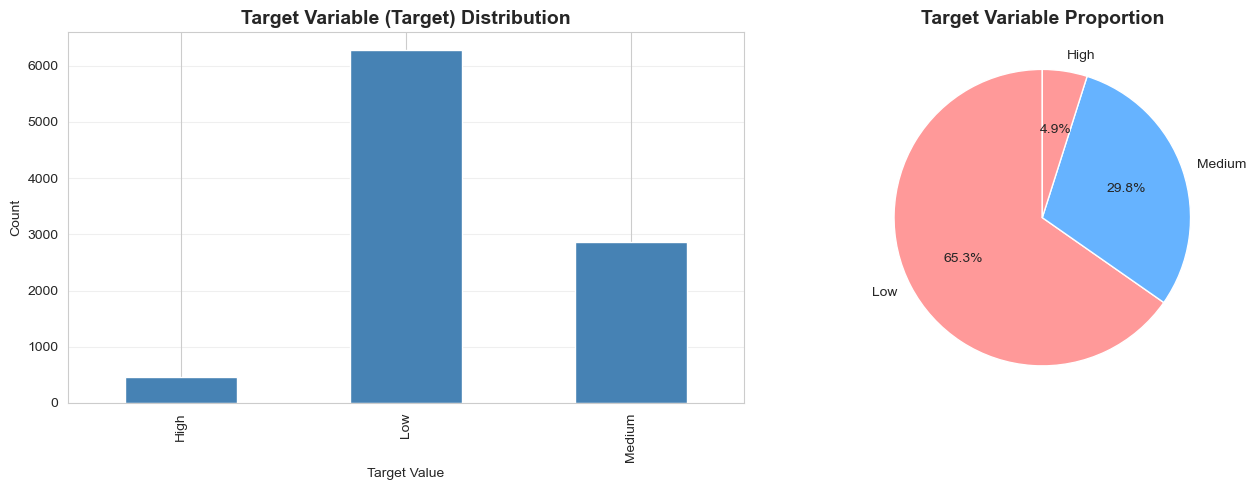


Class is not balanced: 13.36/1


In [26]:
# 2. TARGET VARIABLE ANALYSIS

print('TARGET VARIABLE ANALYSIS')

if 'Target' in train.columns:
    print(f"\nTarget Distribution {train['Target'].value_counts().sort_index()}")
    print(f"\nTarget Distribution {train['Target'].value_counts(normalize = True).sort_index()}")

    # Vizualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Countplot
    train['Target'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Target Variable (Target) Distribution', fontsize = 14, fontweight = 'bold')
    axes[0].set_xlabel('Target Value')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha = 0.3)

    # Pie Chart
    target_count = train['Target'].value_counts()
    axes[1].pie(target_count, labels= target_count.index, autopct = '%1.1f%%',
               startangle = 90, colors=['#ff9999', '#66b3ff'])
    axes[1].set_title('Target Variable Proportion', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.savefig('outputs/figures/target_variable_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Check for Class Imbalance
    class_ratio = train['Target'].value_counts().max() / train['Target'].value_counts().min()
    if class_ratio > 1.5:
        print(f"\nClass is not balanced: {class_ratio:.2f}/1")
    else:
        print(f"\nClass is balanced: {class_ratio:.2f}/1")

# Basic Dataset Information
This section provides a structural overview of the training and test datasets using DataFrame.info().

## What is examined?
For both datasets, the following details are displayed:

## Number of rows and columns
- Column names
- Data types of each feature
- Non-null counts, helping to identify missing values
- Memory usage
  
## Train vs Test
- The training set includes all input features plus the target variable (FHI)
- The test set contains only input features, ensuring no data leakage

In [9]:
# 3. BASIC INFORMATION

print("BASIC INFORMATION")

print("---Train Set Info---")
print(train.info())

print("---Test Set Info---")
print(test.info())

BASIC INFORMATION
---Train Set Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-null   object 

# Missing Values Analysis
This section analyzes missing data patterns in both the training and test datasets, helping identify features that may require imputation, transformation, or removal.

## What the analysis does
For each dataset (train and test):

- Calculates the number of missing values per column
- Computes the percentage of missing values relative to the dataset size
- Filters and displays only columns that contain missing data
- Sorts columns by missing percentage (highest to lowest)

## Tabular Summary
A table is printed showing:

- Column name
- Missing value count
- Percentage of missing values

Missing Values Analysis

TRAIN SET - Columns with Missing Values:
                                                          Column  Missing_count  Percentage
                                            uses_informal_lender           4489   46.672905
                                     uses_friends_family_savings           4488   46.662508
                                      motivation_make_more_money           4291   44.614265
                                               funeral_insurance           4188   43.543356
                                               medical_insurance           4188   43.543356
                                             business_age_months           4111   42.742774
                                         future_risk_theft_stock           4100   42.628405
                                                  has_debit_card           4003   41.619879
                                            has_internet_banking           4003   41.619879
              

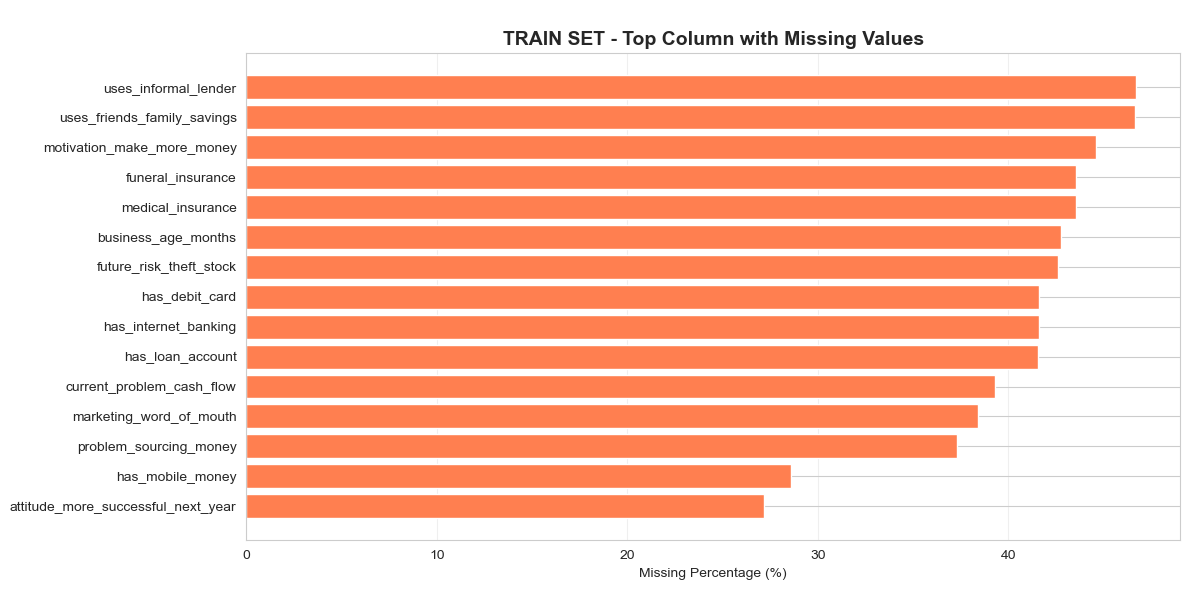


TEST SET - Columns with Missing Values:
                                                          Column  Missing_count  Percentage
                                     uses_friends_family_savings           1131   47.027027
                                            uses_informal_lender           1131   47.027027
                                      motivation_make_more_money           1084   45.072765
                                               funeral_insurance           1042   43.326403
                                               medical_insurance           1042   43.326403
                                             business_age_months           1033   42.952183
                                         future_risk_theft_stock           1017   42.286902
                                                  has_debit_card            992   41.247401
                                                has_loan_account            992   41.247401
                                       

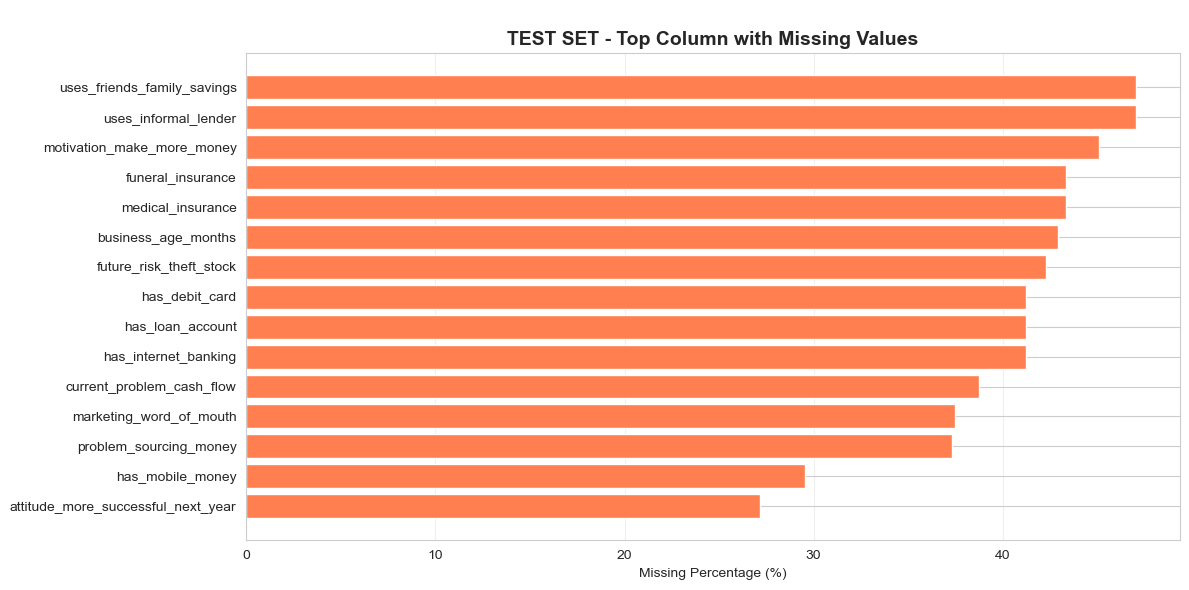

In [27]:
# 4. MISSING VALUES ANALYSIS

print("Missing Values Analysis")

def analyze_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing/ len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_count': missing.values,
        'Percentage': missing_pct.values}).query("Missing_count > 0").sort_values('Percentage', ascending = False)

    print(f"\n{name} - Columns with Missing Values:")
    if len(missing_df) > 0:
        print(missing_df.to_string(index=False))

        # Vizualize top missing values
        if len(missing_df) > 0:
            top_missing = missing_df.head(15)
            plt.figure(figsize=(12, 6))
            plt.barh(top_missing['Column'], top_missing['Percentage'], color = 'coral')
            plt.xlabel('Missing Percentage (%)')
            plt.title(f'\n{name} - Top Column with Missing Values', fontsize = 14, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(axis='x', alpha = 0.3)
            plt.tight_layout()
            plt.savefig('outputs/figures/missing_values.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print("No missing values found")

        return missing_df

train_missing = analyze_missing(train, "TRAIN SET")
test_missing = analyze_missing(test, "TEST SET")

# Numerical Features Analysis
This section examines the numerical variables in the training dataset to understand their distributions, scales, and summary statistics.

## Identifying Numerical Features
- Automatically selects features with int64 and float64 data types
- Excludes the target variable (FHI) to avoid data leakage
- Reports the total number of numerical features and lists their names

## Statistical Summary
- Generates descriptive statistics using .describe():
- Count
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles (25%, 50%, 75%)

## Distribution Visualizations
Plots histograms for selected key numerical features (if present), such as:
- Owner age
- Personal income
- Business expenses
- Business age (in months)
- Uses consistent binning and gridlines for clarity

NUMERICAL FEATURES ANALYSIS

Numerical Columns: 6
['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months']

Statistical Summary
         owner_age  personal_income  business_expenses  business_turnover  \
count  9618.000000     9.509000e+03       9.389000e+03       9.402000e+03   
mean     41.705344     2.627345e+05       4.583838e+05       1.348210e+06   
std      13.314010     2.566268e+06       6.184746e+06       8.804741e+06   
min      18.000000     0.000000e+00       0.000000e+00       0.000000e+00   
25%      32.000000     3.000000e+02       7.000000e+02       1.500000e+03   
50%      40.000000     2.000000e+03       3.000000e+03       6.000000e+03   
75%      50.000000     2.500000e+04       2.500000e+04       5.000000e+04   
max     103.000000     1.500000e+08       5.000000e+08       4.200000e+08   

       business_age_years  business_age_months  
count         9366.000000          5507.000000  
mean             

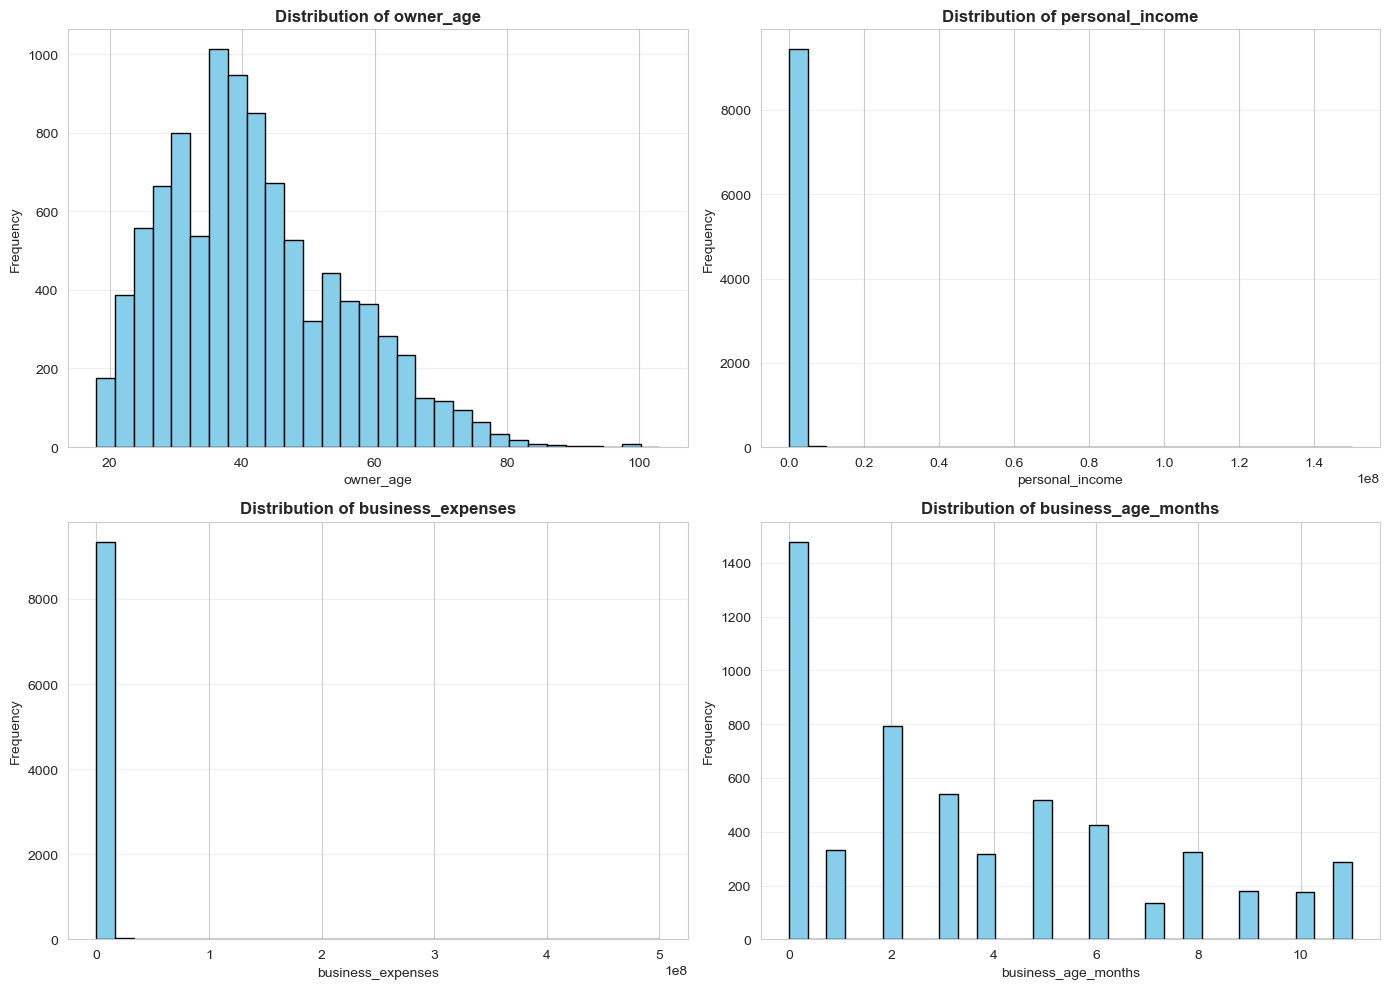

In [28]:
# 5. NUMERICAL FEATURES ANALYSIS

print("NUMERICAL FEATURES ANALYSIS")

# identify numerical columns
numerical_cols = train.select_dtypes(include = ['int64', 'float64']).columns.to_list()
if 'Target' in numerical_cols:
    numerical_cols.remove('Target')

print(f"\nNumerical Columns: {len(numerical_cols)}")
print(numerical_cols)

# Statistical Summary
print("\nStatistical Summary")
print(train[numerical_cols].describe())

# Vizualize distributions of key numerical features
key_numerical = ['owner_age', 'personal_income', 'business_expenses', 'business_age_months']
available_numerical = [col for col in key_numerical if col in train.columns]

if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize = (14, 10))
    axes = axes.ravel()

    for idx, col in enumerate(available_numerical[:4]):
        train[col].hist(bins = 30, ax=axes[idx], color = 'skyblue', edgecolor = 'black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('outputs/figures/numerical_features.png', dpi=150, bbox_inches='tight')
    plt.show()

# Categorical Features Analysis
This section explores the categorical variables in the training dataset, focusing on their quantity, variety, and uniqueness.

## Identifying Categorical Features
- Selects all features with object data types
- Excludes the ID column, as it serves only as an identifier and carries no predictive value
- Displays the total number of categorical features and their names

## Cardinality Analysis
For each categorical feature, the analysis computes:

## Number of unique values (cardinality)
The results are presented in a sorted table, from highest to lowest cardinality.

In [12]:
# 6. CATEGORICAL FEATURES ANALYSIS

print("CATEGORICAL FEATURES ANALYSIS")

# Identify categorical columns
categorical_cols = train.select_dtypes(include=['object']).columns.to_list()
if 'ID' in categorical_cols:
    categorical_cols.remove("ID")

print(f"\nNumber of Categorical Features ({len(categorical_cols)}):")
print(categorical_cols)

# Cardinality Analysis
print("\nCardinality (Unique Values) for Categorical Features:")
cardinality_df = pd.DataFrame({
    'Columns': categorical_cols,
    'Unique_Values': [train[col].nunique() for col in categorical_cols]
}).sort_values('Unique_Values', ascending = False)
print(cardinality_df.to_string(index = False))

CATEGORICAL FEATURES ANALYSIS

Number of Categorical Features (32):
['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender', 'Target']

Cardinality (Unique Values) for Categorical Features:
     

# Country Distribution
This section analyzes how observations are distributed across countries in both the training and test datasets.

## Frequency Analysis
Displays the count of records per country in:
- The training dataset
- The test dataset
- Helps verify whether both datasets reflect similar geographic coverage.

## Visualization
Two bar charts are generated side by side:

- Train Set Country Distribution
- Test Set Country Distribution

The charts:
- Show sample size differences across countries
- Highlight potential regional imbalance
- Rotate x-axis labels for improved readability

COUNTRY DISTRIBUTION
Train Set Country Distribution
country
eswatini    669
zimbabwe    653
malawi      597
lesotho     486
Name: count, dtype: int64
Train Set Country Distribution
country
eswatini    669
zimbabwe    653
malawi      597
lesotho     486
Name: count, dtype: int64


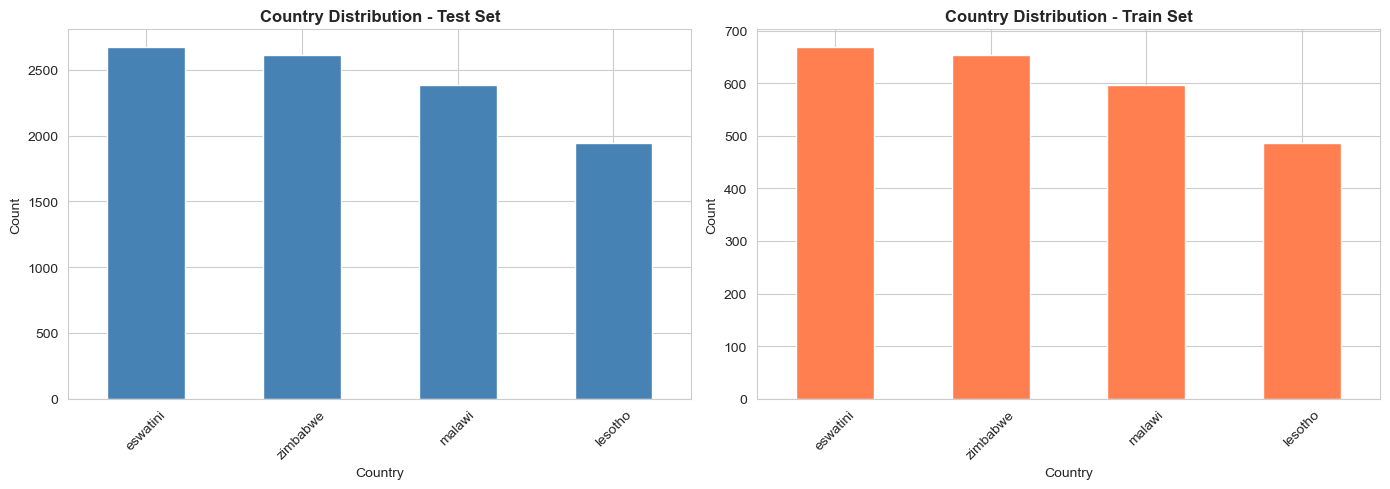

In [29]:
# 7. COUNTRY DISTRIBUTION

print("COUNTRY DISTRIBUTION")
if 'country' in train.columns:
     print("Train Set Country Distribution")
     print(test['country'].value_counts())

     print("Train Set Country Distribution")
     print(test['country'].value_counts())

     # Vizualize
     fig, axes = plt.subplots(1, 2, figsize = (14,5))

     train['country'].value_counts().plot(kind='bar', ax = axes[0], color ='steelblue')
     axes[0].set_title('Country Distribution - Test Set', fontsize = 12, fontweight = 'bold')
     axes[0].set_xlabel("Country")
     axes[0].set_ylabel("Count")
     axes[0].tick_params(axis='x', rotation= 45)

     test['country'].value_counts().plot(kind='bar', ax = axes[1], color ='coral')
     axes[1].set_title('Country Distribution - Train Set', fontsize = 12, fontweight = 'bold')
     axes[1].set_xlabel("Country")
     axes[1].set_ylabel("Count")
     axes[1].tick_params(axis='x', rotation= 45)

     plt.tight_layout()
     plt.savefig('outputs/figures/country_distribution.png', dpi=150, bbox_inches='tight')
     plt.show()

# Binary / Categorical Feature Patterns
This section inspects binary and simple categorical features, particularly those with Yes/No or similar responses.

## Identifying Yes/No Features
- Filters categorical columns for those containing values like:
    - "Yes"
    - "No"
    - "Don't know or N/A"
These columns often represent binary or ternary responses.

## Frequency Analysis
- Prints the value counts for the first few Yes/No type columns
- Helps identify:
    - Distribution of responses
    - Potential class imbalance in binary features
    - Features that may require encoding as 0/1 or categorical labels

In [14]:
# 8. BINARY OR CATEGORICAL FEATURE PATTERNS

print("BINARY OR CATEGORICAL PATTERNS")

# Analyze Yes/No Columns
yes_no_columns = [col for col in categorical_cols if train[col].dropna().isin(['Yes', 'No', "Don't know or N/A"]).any()]

print(f"\nYes/No Type Columns ({len(yes_no_columns)}):")
for col in yes_no_columns[:5]:    #Show first 5
    print(f"\n{col}:")
    print(train[col].value_counts())

BINARY OR CATEGORICAL PATTERNS

Yes/No Type Columns (19):

attitude_stable_business_environment:
attitude_stable_business_environment
Yes                  5820
No                   2451
Don’t know or N/A    1345
Name: count, dtype: int64

attitude_worried_shutdown:
attitude_worried_shutdown
No                   5804
Yes                  3575
Don’t know or N/A     237
Name: count, dtype: int64

compliance_income_tax:
compliance_income_tax
No            8010
Yes           1252
Don’t know     341
Refused         11
Name: count, dtype: int64

perception_insurance_doesnt_cover_losses:
perception_insurance_doesnt_cover_losses
No            4486
Yes           2604
Don't know    2523
Name: count, dtype: int64

perception_cannot_afford_insurance:
perception_cannot_afford_insurance
Yes           6056
No            2093
Don't know    1464
Name: count, dtype: int64


# Feature Relationships with Target (FHI)
This section examines how key features relate to the target variable (FHI) to identify potential predictors and patterns.

## Numerical Features vs Target
- Computes mean, median, standard deviation, and count of numerical features grouped by each FHI class
- Helps detect:
    - Trends or differences between classes
    - Features that may have strong predictive power
    - Variability that could influence model performance
## Categorical Features vs Target
- Uses cross-tabulation to calculate the percentage distribution of categories within each FHI class
- Key categorical features analyzed:
    - country
    - compliance_income_tax
    - medical_insurance
- Highlights potential correlations between categorical features and the target

In [15]:
# 9. FEATURE RELATIONSHIPS WITH TARGET
if 'Target' in train.columns:
     print("FEATURE RELATIONSHIPS WITH TARGET")

     # Numerical features vs Target
     print("\nNumerical Features by Target:")
     if available_numerical:
         for col in available_numerical[:3]:   # Top 3
             print(f"\n{col} by Target")
             grouped_stats = train.groupby("Target")[col].agg(["mean","median", "std", "count"])
             print(grouped_stats)

    # Categorical Features vs Target
     print("\nKey Categorical Features by Target:")
     key_cat = ['country', 'compliance_income_tax', 'medical_insurance']
     for col in key_cat:
         if col in train.columns:
             print(f"\n{col} distribution by Target:")
             ct = pd.crosstab(train[col], train['Target'], normalize= 'index') * 100
             print(ct.round(2))


FEATURE RELATIONSHIPS WITH TARGET

Numerical Features by Target:

owner_age by Target
             mean  median        std  count
Target                                     
High    44.610638    42.0  11.881589    470
Low     40.732962    39.0  13.333695   6280
Medium  43.358438    42.0  13.264731   2868

personal_income by Target
                 mean  median           std  count
Target                                            
High    882802.239224  5000.0  4.715191e+06    464
Low     254094.823039  2000.0  2.546815e+06   6209
Medium  180199.970205  1500.0  2.045196e+06   2836

business_expenses by Target
                mean   median           std  count
Target                                            
High    1.062801e+06  10100.0  8.584024e+06    464
Low     4.855686e+05   3000.0  6.866861e+06   6137
Medium  2.979526e+05   2000.0  3.564138e+06   2788

Key Categorical Features by Target:

country distribution by Target:
Target     High    Low  Medium
country                    

# Data Quality Checks
This section performs key data integrity checks to ensure the dataset is reliable and ready for modeling.

## Duplicate ID Check
- Counts duplicate IDs in both train and test sets
- Duplicate identifiers may indicate repeated records, which can bias model training
## Train-Test ID Overlap
- Identifies IDs present in both train and test sets
- Overlapping IDs could lead to data leakage and inflated model performance
## Feature Consistency Check
- Compares columns in train and test datasets (excluding the target FHI)
- Detects:
    - Features present in train but missing in test
    - Features present in test but missing in train
    - Ensures that both datasets are aligned for modeling

In [16]:
# 10. DATA QUALITY CHECKS

print("DATA QUALITY CHECKS")


# Check for ID duplicates
print(f"\nTrain ID Duplicates: {train['ID'].duplicated().sum()}")
print(f"\nTest ID Duplicates: {test['ID'].duplicated().sum()}")

# Check for overlapping ID
id_overlap = set(train['ID']).intersection(set(test['ID']))
print(f"\nOverlapping IDs between Train and Test: {len(id_overlap)}")

# Check feature consistency
train_cols = set(train.columns) - {'FHI'}
test_cols = set(test.columns)
missing_in_test = train_cols - test_cols
extra_in_test = test_cols - train_cols

if missing_in_test:
    print(f"\n⚠ Features in Train but not in Test: {missing_in_test}")
if extra_in_test:
    print(f"\n⚠ Features in Test but not in Train: {extra_in_test}")
if not missing_in_test and not extra_in_test:
    print("\n✓ Feature sets are consistent (except target variable)")

DATA QUALITY CHECKS

Train ID Duplicates: 0

Test ID Duplicates: 0

Overlapping IDs between Train and Test: 0

⚠ Features in Train but not in Test: {'Target'}


# Key Insights & Recommendations
This final section summarizes the main findings from the exploratory data analysis (EDA) and outlines actionable next steps for modeling.

## EDA Summary
- Total training samples: `len(train_df)`
- Total test samples: `len(test_df)`
- Number of features: `len(categorical_cols) + len(numerical_cols)`
- Numerical features: `len(numerical_cols)`
- Categorical features: `len(categorical_cols)`

## Missing Data
- Features with missing values: `len(train_missing)`
- Maximum missing percentage: `train_missing['Percentage'].max():.1f%`

In [17]:
# 11. KEY INSIGHTS SUMMARY

print("KEY INSIGHTS & RECOMMENFDATIONS")

print("\n📊 EDA SUMMARY:")
print(f"• Total training samples: {len(train):,}")
print(f"• Total test samples: {len(test):,}")
print(f"• Number of features: {len(categorical_cols) + len(numerical_cols)}")
print(f"• Numerical features: {len(numerical_cols)}")
print(f"• Categorical features: {len(categorical_cols)}")

if len(train_missing) > 0:
    print(f"\n⚠ Missing Data:")
    print(f"• Features with missing values: {len(train_missing)}")
    print(f"• Highest missing percentage: {train_missing['Percentage'].max():.1f}%")

print("\n💡 NEXT STEPS:")
print("1. Handle missing values (imputation or feature engineering)")
print("2. Encode categorical variables (Label/One-Hot encoding)")
print("3. Scale numerical features if needed")
print("4. Consider feature engineering based on domain knowledge")
print("5. Handle class imbalance if present")
print("6. Train baseline models and iterate")

print("EDA COMPLETE!")

KEY INSIGHTS & RECOMMENFDATIONS

📊 EDA SUMMARY:
• Total training samples: 9,618
• Total test samples: 2,405
• Number of features: 38
• Numerical features: 6
• Categorical features: 32

⚠ Missing Data:
• Features with missing values: 35
• Highest missing percentage: 46.7%

💡 NEXT STEPS:
1. Handle missing values (imputation or feature engineering)
2. Encode categorical variables (Label/One-Hot encoding)
3. Scale numerical features if needed
4. Consider feature engineering based on domain knowledge
5. Handle class imbalance if present
6. Train baseline models and iterate
EDA COMPLETE!


# Next Steps
- Handle missing values (imputation, dropping, or feature engineering)
- Encode categorical variables (Label Encoding, One-Hot Encoding, or target/frequency encoding)
- Scale numerical features if needed (standardization, min-max scaling, or log-transform)
- Feature engineering using domain knowledge to create meaningful predictors
- Address class imbalance if detected in the target variable
- Train baseline models and iteratively improve performance

## EDA Complete
This concludes the initial exploration. The dataset is now ready for preprocessing, feature engineering, and model development.

## Feature Engineering - Getting Started
In this section, we demonstrate how to create new features to boost model performance.
We focus on two powerful features derived from domain knowledge:
1. Profit Margin Ratio  
**Concept**: Measures business profitability relative to income.  
**Formula**: (personal_income - business_expenses) / personal_income.

2. Financial Access Score  
**Concept**: Measures access to formal financial services.  
**Includes**: Bank accounts, loans, internet banking, debit cards, insurance.

FEATURE ENGINEERING
Profit Margin Ratio

Created 'profit_margin' feature
  Train - Non-null values: 9338
  Test - Non-null values: 2322

Sample statistics:
count    9338.000000
mean       -0.200178
std         0.796198
min        -1.000000
25%        -1.000000
50%        -0.285714
75%         0.600000
max         1.000000
Name: profit_margin, dtype: float64

📊 Profit Margin by Target:
            mean    median       std
Target                              
High   -0.278023 -0.500000  0.762552
Low    -0.193241 -0.250000  0.800371
Medium -0.202494 -0.333333  0.792035


<Figure size 1000x500 with 0 Axes>

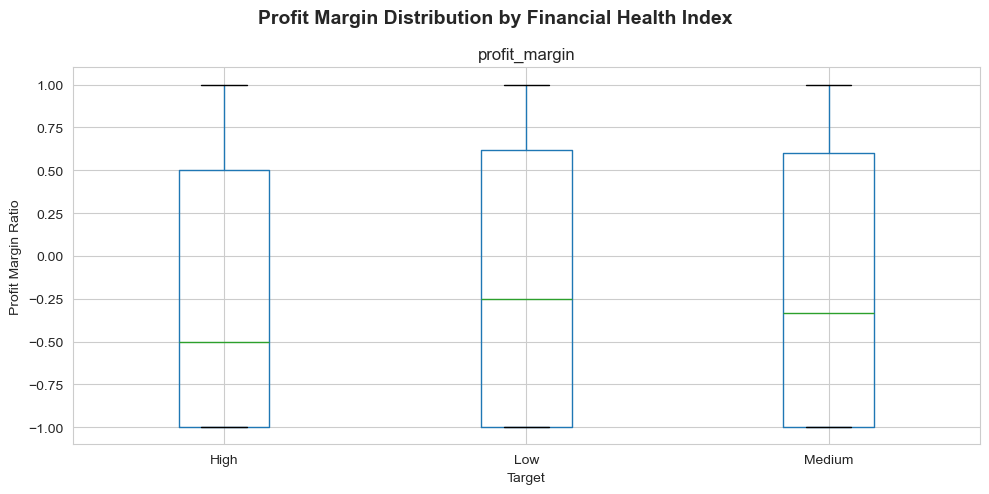

FINANCIAL ACCESS SCORE
Concept: How many formal financial services does the business use?
Includes: bank accounts, debit cards, internet banking, loans, insurance

Created 'financial_access_score' feature
  Train - Non-null values: 8228
  Test - Non-null values: 2066
Sample Statistics
count    8228.000000
mean        0.189297
std         0.276240
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
Name: financial_access_score, dtype: float64

Financial Access Score by Target:
            mean    median       std
Target                              
High    0.490086  0.400000  0.248168
Low     0.091164  0.000000  0.208255
Medium  0.372129  0.333333  0.292329


<Figure size 1000x500 with 0 Axes>

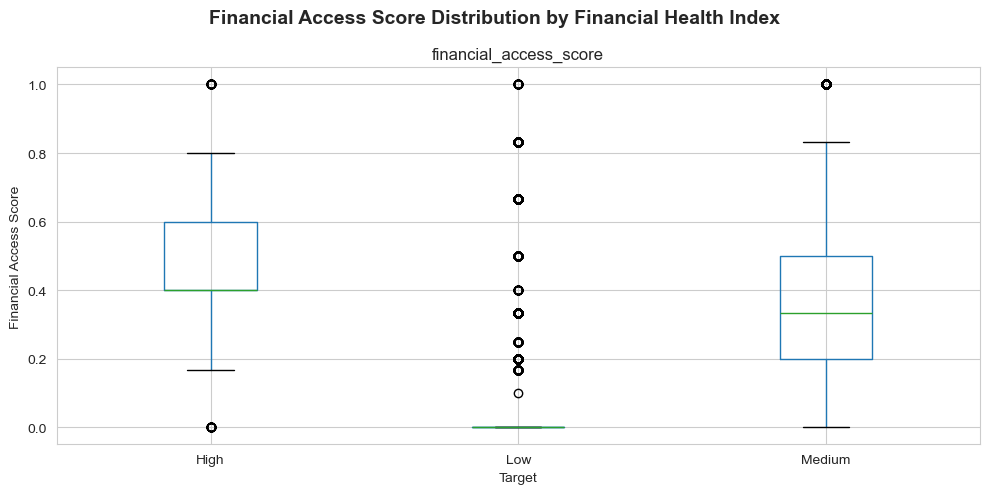


Your engineered dataframes are ready:
   • train_fe: (9618, 41)
   • test_fe: (2405, 40)


In [32]:
# 12. FEATURE ENGINEERING

print("FEATURE ENGINEERING")

train_fe = train.copy()
test_fe = test.copy()

# Feature 1. Profit Margin Ratio
print("Profit Margin Ratio")

def create_profit_margin(df):
    """
    Calculate profit margin ratio for each business.
    This indicates financial efficiency and sustainability.
    """
    # Handle division by zero and missing values
    profit_margin = []
    
    for idx, row in df.iterrows():
        income = row.get('personal_income', np.nan)
        expenses = row.get('business_expenses', np.nan)
        
        # Check if both values exist and income is not zero
        if pd.notna(income) and pd.notna(expenses) and income != 0:
            margin = (income - expenses) / income
            # Cap extreme values
            margin = max(-1, min(margin, 1))  # Keep between -1 and 1
        else:
            margin = np.nan
        
        profit_margin.append(margin)
    
    return profit_margin

train_fe['profit_margin'] = create_profit_margin(train_fe)
test_fe['profit_margin'] = create_profit_margin(test_fe)

print(f"\nCreated 'profit_margin' feature")
print(f"  Train - Non-null values: {train_fe['profit_margin'].notna().sum()}")
print(f"  Test - Non-null values: {test_fe['profit_margin'].notna().sum()}")
print("\nSample statistics:")
print(train_fe['profit_margin'].describe())

# Show relationship with target
if 'Target' in train_fe.columns:
    print("\n📊 Profit Margin by Target:")
    print(train_fe.groupby('Target')['profit_margin'].agg(['mean', 'median', 'std']))

    # Visualize
    plt.figure(figsize=(10, 5))
    train_fe.boxplot(column='profit_margin', by='Target', figsize=(10, 5))
    plt.suptitle('Profit Margin Distribution by Financial Health Index', 
                 fontsize=14, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel('Profit Margin Ratio')
    plt.tight_layout()
    plt.show()


# Feature 2. Financial Access Score
print("FINANCIAL ACCESS SCORE")
print("Concept: How many formal financial services does the business use?")
print("Includes: bank accounts, debit cards, internet banking, loans, insurance")

def create_financial_access_score(df): 
    """
    Calculate a composite score of financial service access.
    Higher score = better access to formal financial services.
    """
    financial_features = [
        'has_bank_account', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'medical_insurance', 'funeral_insurance']

    # Available Features in the Dataset
    available_features = [col for col in financial_features if col in df.columns]

    scores = []
    for idx, row in df.iterrows():
        score = 0
        valid_features = 0

        for features in available_features:
            value = row.get(features, np.nan)

            if pd.notna(value):
                valid_features += 1
                # Check for positive responses
                if value in ['Yes', 'Have now', 'have now']:
                    score += 1
                elif value in ['Used to have but don\'t have now', 'used to have']:
                    score += 0.5 # Partial credit for past access


        # Normalize by number of valid features checked
        if valid_features > 0:
            normalized_score = score / valid_features
        else:
            normalized_score = np.nan

        scores.append(normalized_score)

    return scores

train_fe['financial_access_score'] = create_financial_access_score(train_fe)
test_fe['financial_access_score'] = create_financial_access_score(test_fe)

print(f"\nCreated 'financial_access_score' feature")
print(f"  Train - Non-null values: {train_fe['financial_access_score'].notna().sum()}")
print(f"  Test - Non-null values: {test_fe['financial_access_score'].notna().sum()}")
print("Sample Statistics")
print(train_fe['financial_access_score'].describe())

# Show relationship with target
if 'Target' in train_fe.columns:
    print("\nFinancial Access Score by Target:")
    print(train_fe.groupby("Target")['financial_access_score'].agg(['mean', 'median','std']))

    # Vizualize
    plt.figure(figsize = (10,5))
    train_fe.boxplot(by='Target', column='financial_access_score', figsize=(10,5))
    plt.suptitle('Financial Access Score Distribution by Financial Health Index', fontsize=14, fontweight='bold')
    plt.xlabel("Target")
    plt.ylabel("Financial Access Score")
    plt.tight_layout()
    plt.savefig('outputs/figures/profit_margin_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()



# Save engineered datasets (optional)
print("\nYour engineered dataframes are ready:")
print(f"   • train_fe: {train_fe.shape}")
print(f"   • test_fe: {test_fe.shape}")

# Preparing Features and Target
Before training a model, we separate the predictors from the target variable and prepare the test dataset.

## Training Data
- X: Features for training (train_fe without FHI and ID)
- y: Target variable (FHI)
- X = train_fe.drop(columns=['Target', 'ID'])
- y = train_fe['Target']
## Test Data
- X_test: Features for prediction (test_fe without ID)
- X_test = test_fe.drop(columns=['ID'])

In [19]:
X = train_fe.drop(columns=['Target', 'ID'])
y = train_fe['Target']

X_test = test_fe.drop(columns=['ID'])

# Converting Object Columns to Categorical
Many machine learning algorithms perform better when categorical variables are explicitly typed. 
Here, we convert all object-type columns in X and X_test to category data type.

## Function: change_object_to_cat
- Takes a DataFrame as input
- Converts all object columns to category
- Returns:
    1. Updated DataFrame
    2. List of columns that were converted

In [20]:
def change_object_to_cat(df):
    # changes object to category and returns dataframe and list
    
    df = df.copy()
    list_cols = df.columns[df.dtypes == "object"].tolist()
    for str_cols in list_cols:
        df[str_cols] = df[str_cols].astype("category")

    return df, list_cols
X, cat_list = change_object_to_cat(X)
X_test, cat_list = change_object_to_cat(X_test)

# Train-Validation Split
Before training models, it’s important to split the dataset into training and validation sets.  
This allows us to evaluate model performance on unseen data.

## How the split works
- Training set (X_train, y_train): 80% of the data
- Validation set (X_val, y_val): 20% of the data
- Random state = 42 ensures reproducibility
## Stratification
- Stratified by country and target (FHI) to preserve the original distribution across both dimensions
- Ensures balanced representation in both training and validation sets.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify= train[['country', 'Target']])

# Model Training with LightGBM
We train a LightGBM classifier to predict the target variable (FHI) and evaluate its performance.

## 1. Initialize and Train Model
LightGBM is a gradient boosting framework optimized for speed and performance.  
Handles categorical features efficiently and scales well to large datasets.

---

## 2. Make Predictions

---

## 3. Evaluate Model
Classification report: shows precision, recall, F1-score for each class  
Confusion matrix: visualizes true vs predicted labels

---

## 4. Feature Importance
Identifies the most influential features for the model.  
Helps guide feature selection and engineering for future iterations.

In [22]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 4. Train LightGBM

model = LGBMClassifier()
model.fit(X_train, y_train)

# 5. Predict 

y_pred = model.predict(X_val)

# 6. Evaluation

print("Classification Report:")
print(classification_report(y_val, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# 7. Extract top 50 most important features

feature_important = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_})

top50 = feature_important.sort_values("importance", ascending= False).head(50)
print("Top 50 Features:")
print(top50)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1308
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 39
[LightGBM] [Info] Start training from score -3.015951
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210580
Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.59      0.71        93
         Low       0.89      0.97      0.92      1256
      Medium       0.84      0.72      0.78       575

    accuracy                           0.88      1924
   macro avg       0.88      0.76      0.81      1924
weighted avg       0.87      0.88      0.87      1924

Confusion Matrix:
[[  55    2   36]
 [   0 1216   40]
 [   6  156  413]]
Top 50 Fe

# Generating Predictions and Submission File
After training the model, we generate predictions on the test set and prepare a submission file.

## Predict on Test Data
predictions = model.predict(X_test)
## Create Submission DataFrame
pred_df = pd.DataFrame({ 
    "ID": test_df["ID"].values,  
    "pred_FHI": predictions 
})  
- Combines the ID column from the test set with predicted FHI values
- Ensures the submission matches the required format
## Save to CSV
pred_df.to_csv('submission.csv', index=False) 
- Saves the submission file locally as submission.csv
- Ready to upload for evaluation
## Preview Predictions
pred_df.head()
- Displays the first few rows of predicted results for verification

In [23]:
predictions = model.predict(X_test)

pred_df = pd.DataFrame({
    "ID": test['ID'].values,
    "Target": predictions})

pred_df.to_csv('submission.csv', index=False)

pred_df

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low
...,...,...
2400,ID_FX7XJZ,Low
2401,ID_XAL1LX,Low
2402,ID_UHBP0F,Medium
2403,ID_GKIKR2,Medium
